# Abundance concordance across the detection-threshold sweep

Companion to `sensitivity_floor.ipynb`. The detection sweep showed precision and F1 swinging sharply
with the threshold. Here we run the same threshold sweep, but score the three abundance concordance
metrics used in the main abundance analysis: Spearman rho (rank), 1 - Bray-Curtis (1-BC, magnitude),
and 1 - Jensen-Shannon (1-JSD, full distribution).

Setup mirrors `analysis_abundance.ipynb`: each tool's reported relative abundance and the theoretical
composition are normalized to sum 1 and compared over the union of taxids. The threshold is applied to
the predicted relative abundance in percent (predicted taxa below the threshold are dropped and the
remainder renormalized), matching the detection sweep and agreeing with the threshold-0 case.

Mock D6331 only (four libraries: two PacBio HiFi, two ONT), unified database. Outputs go to
`results/<TS>/auxiliary/abundance_sweep/`.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from IPython.display import display

BAKEOFF_ROOT = next((d for d in [Path.cwd(), *Path.cwd().parents]
                     if (d / 'config' / 'bakeoff_env.yaml').is_file()), None)
if BAKEOFF_ROOT is None:
    raise RuntimeError(f'Could not locate bakeoff/ root from {Path.cwd()}')
os.chdir(BAKEOFF_ROOT)
sys.path.insert(0, str(BAKEOFF_ROOT / 'scripts' / 'analysis'))

from utils.util import apply_taxid_synonyms
from utils.results import RESULTS_SUBDIR, find_latest_analysis_prep_ts, save_csv, save_fig

# Configuration
SAVE              = True
RESULTS_ROOT      = BAKEOFF_ROOT / 'results'
TS                = find_latest_analysis_prep_ts(RESULTS_ROOT)   # or pin: TS = 'YYYYMMDD_HHMMSS'
PREP_DIR          = RESULTS_ROOT / RESULTS_SUBDIR / TS / 'analysis-prep'
ABUND_DIR         = PREP_DIR / 'tables' / 'abundance'
GT_DIR            = PREP_DIR / 'truth'
OUT_DIR           = RESULTS_ROOT / TS / 'auxiliary' / 'abundance_sweep'

RANKS             = ['species', 'genus']
SWEEP             = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]    # predicted relative-abundance threshold (%)
SYNONYM_TAXID_MAP = {1578: 2742598}
SKETCH_TOOLS      = {'Sourmash', 'Sylph'}
TOOLS             = ['Centrifuge_unified', 'Centrifuger_unified', 'Kraken2_unified',
                     'Ganon2_unified', 'Sourmash_unified', 'Sylph_unified']
TOOL_ORDER        = ['Kraken2', 'Centrifuge', 'Centrifuger', 'Ganon2', 'Sourmash', 'Sylph']
ZYMO_MOCKS        = [('pacbio', 'SRR13128013'), ('pacbio', 'SRR13128014'),
                     ('ont', 'D6331_Zymo'), ('ont', 'D6331_Qiagen')]

_TAB10 = plt.get_cmap('tab10')
TOOL_COLORS = {'Centrifuge': _TAB10(0), 'Centrifuger': _TAB10(1), 'Kraken2': _TAB10(2),
               'Ganon2': _TAB10(3), 'Sourmash': _TAB10(4), 'Sylph': _TAB10(5)}
def tool_color(tool): return TOOL_COLORS.get(str(tool), (0.5, 0.5, 0.5, 1.0))
def tool_class(tool): return 'sketch' if str(tool).split('_')[0] in SKETCH_TOOLS else 'classifier'
def is_sketch(base):  return base in SKETCH_TOOLS

TITLE_KW = dict(fontsize=14, fontweight='bold', pad=12)
LABEL_FS = 12

# Concordance metrics (same definitions as analysis_abundance.ipynb).
def bray_curtis(gt, pred):
    return 0.5 * np.abs(np.asarray(gt, float) - np.asarray(pred, float)).sum()

def jsd(p, q):
    p = np.asarray(p, float); q = np.asarray(q, float)
    if p.sum() > 0: p = p / p.sum()
    if q.sum() > 0: q = q / q.sum()
    m  = 0.5 * (p + q)
    kl = lambda a: np.sum(a[a > 0] * np.log2(a[a > 0] / m[a > 0]))
    return float(np.clip(0.5 * (kl(p) + kl(q)), 0.0, 1.0))

def _clean_taxid(df):
    df = df.copy()
    df['taxid'] = pd.to_numeric(df['taxid'], errors='coerce').astype('Int64')
    return df.dropna(subset=['taxid']).reset_index(drop=True)

zgt = pd.read_csv(GT_DIR / 'zymoD6331_gt.csv')

def _truth_fractions(rank):
    g = _clean_taxid(zgt.query('rank == @rank')[['taxid', 'abundance']])
    g = apply_taxid_synonyms(g, abundance_col='abundance', synonyms=SYNONYM_TAXID_MAP,
                             collapse=True, source_label=f'GT_{rank}')
    g['taxid'] = g['taxid'].astype(int)
    s = g.groupby('taxid')['abundance'].sum()
    return s / s.sum()

def _pred_fractions(tool_db, tech, samp, rank):
    # taxid -> relative-abundance fraction (sum 1) for one (tool, mock), synonym-collapsed.
    p = ABUND_DIR / tool_db / f'ZymoMockD6331_{tech}_{samp}.csv'
    if not p.is_file():
        return pd.Series(dtype=float)
    df = _clean_taxid(pd.read_csv(p).query('rank == @rank')[['taxid', 'value']])
    df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0.0)
    df = apply_taxid_synonyms(df, abundance_col='value', synonyms=SYNONYM_TAXID_MAP,
                              collapse=True, source_label=tool_db)
    df['taxid'] = df['taxid'].astype(int)
    s = df.groupby('taxid')['value'].sum()
    return s / s.sum() if s.sum() > 0 else s

TRUTH = {rank: _truth_fractions(rank) for rank in RANKS}
PRED  = {(t, tech, samp, rank): _pred_fractions(t, tech, samp, rank)
         for t in TOOLS for (tech, samp) in ZYMO_MOCKS for rank in RANKS}
print(f'ts:  {TS}')
print(f'out: {OUT_DIR}  (SAVE={SAVE})')
print('truth species/genus taxa:', {r: len(TRUTH[r]) for r in RANKS})

[Synonyms:Centrifuge_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuger_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Kraken2_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Kraken2_unified] 1 taxids replaced (examples: {np.int64(1578): 2742598})
ts:  20260713_014947
out: /home/Users/pacbio_bakeoff/bakeoff/results/20260713_014947/auxiliary/abundance_sweep  (SAVE=True)
truth species/genus taxa: {'species': 17, 'genus': 17}


## Sweep computation

For each (tool, mock, rank, threshold): drop predicted taxa below the threshold, renormalize, align
to the theoretical composition over the union of taxids, and compute Spearman rho, 1-BC, and 1-JSD.
Metrics are then averaged over the four mocks (band = min to max).

In [2]:
def _concordance(truth, pred):
    idx = truth.index.union(pred.index)
    gv  = truth.reindex(idx, fill_value=0.0).values
    pv  = pred.reindex(idx, fill_value=0.0).values
    rho, _ = spearmanr(gv, pv)
    return dict(rho=float(rho), one_minus_BC=1 - bray_curtis(gv, pv), one_minus_JSD=1 - jsd(gv, pv))

rows = []
for rank in RANKS:
    truth = TRUTH[rank]
    for t in TOOLS:
        base = t.replace('_unified', '')
        for thr in SWEEP:
            for tech, samp in ZYMO_MOCKS:
                fr   = PRED[(t, tech, samp, rank)]
                keep = fr[fr * 100 >= thr] if thr > 0 else fr[fr > 0]
                pred = keep / keep.sum() if keep.sum() > 0 else keep
                m = _concordance(truth, pred)
                rows.append(dict(rank=rank, tool=base, tool_class=tool_class(t), threshold=thr, **m))
permock = pd.DataFrame(rows)

METRICS = ['rho', 'one_minus_BC', 'one_minus_JSD']
agg = (permock.melt(id_vars=['rank', 'tool', 'tool_class', 'threshold'],
                    value_vars=METRICS, var_name='metric', value_name='v')
       .groupby(['rank', 'tool', 'tool_class', 'threshold', 'metric'])
       .agg(mean=('v', 'mean'), lo=('v', 'min'), hi=('v', 'max')).reset_index())
save_csv(agg, OUT_DIR / 'abundance_sweep_detail.csv', SAVE, index=False)
display(agg.query('rank == "species" and metric == "rho"')
           .pivot_table(index='tool', columns='threshold', values='mean').reindex(TOOL_ORDER).round(3))

threshold,0.0000,0.0001,0.0010,0.0100,0.1000
tool,,,,,
Kraken2,0.311,0.358,0.487,0.706,0.810
Centrifuge,0.306,0.333,0.317,0.280,0.189
Centrifuger,0.583,0.602,0.677,0.761,0.847
Ganon2,0.688,0.750,0.832,0.886,0.890
Sourmash,0.852,0.852,0.851,0.912,0.915
Sylph,0.808,0.808,0.808,0.831,0.817


## Figure: concordance vs threshold (species)

Lines are colored by tool; the band spans min to max over the four mocks.
1-BC and 1-JSD are nearly flat: the false positives removed by thresholding carry negligible abundance
mass, so magnitude-based concordance is largely threshold-insensitive. Only the rank-based Spearman rho
responds, and there the classifiers improve while Centrifuge stays the outlier.

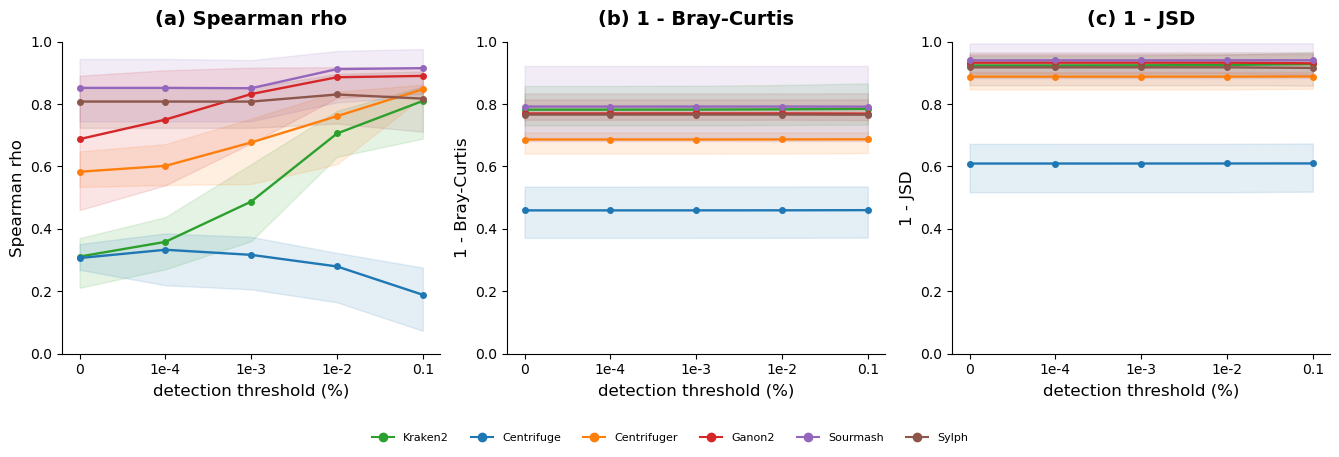

In [3]:
RANK = 'species'
PANELS = [('rho', 'Spearman rho'), ('one_minus_BC', '1 - Bray-Curtis'), ('one_minus_JSD', '1 - JSD')]
xpos = list(range(len(SWEEP)))
xmap = dict(zip(SWEEP, xpos))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True)
for k, (ax, (metric, label)) in enumerate(zip(axes, PANELS)):
    sub = agg.query('rank == @RANK and metric == @metric')
    for tool in TOOL_ORDER:
        g = sub[sub.tool == tool].sort_values('threshold')
        if g.empty:
            continue
        x   = [xmap[t] for t in g.threshold]
        col = tool_color(tool)
        ax.fill_between(x, g['lo'], g['hi'], color=col, alpha=0.12, zorder=1)
        ax.plot(x, g['mean'], '-', color=col,
                marker='o', ms=4, lw=1.7, zorder=3)
    ax.set_xticks(xpos); ax.set_xticklabels(['0', '1e-4', '1e-3', '1e-2', '0.1'])
    ax.set_xlabel('detection threshold (%)', fontsize=LABEL_FS)
    ax.set_ylabel(label, fontsize=LABEL_FS)
    ax.set_ylim(0, 1)
    ax.set_title(f'({chr(97 + k)}) {label}', **TITLE_KW)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)

tool_handles = [Line2D([], [], color=tool_color(t), marker='o', ls='-', label=t) for t in TOOL_ORDER]
fig.legend(handles=tool_handles, loc='lower center', ncol=6,
           frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.05, 1, 1))
save_fig(fig, OUT_DIR / 'abundance_sweep_species.png', SAVE, dpi=200); plt.show()

## Summary: threshold sensitivity per metric

Range of each metric across the sweep (max - min over thresholds), per tool. Near-zero for 1-BC and
1-JSD confirms abundance accuracy is threshold-robust; Spearman rho shows the largest swings.

In [4]:
rng = (agg.query('rank == "species"')
          .groupby(['metric', 'tool'])
          .agg(min_v=('mean', 'min'), max_v=('mean', 'max')).reset_index())
rng['range'] = (rng['max_v'] - rng['min_v']).round(3)
summary = rng.pivot(index='tool', columns='metric', values='range').reindex(TOOL_ORDER)
summary = summary[['rho', 'one_minus_BC', 'one_minus_JSD']]
display(summary)
save_csv(summary, OUT_DIR / 'abundance_sweep_range.csv', SAVE, index=True)

metric,rho,one_minus_BC,one_minus_JSD
tool,,,
Kraken2,0.499,0.003,0.004
Centrifuge,0.144,0.001,0.000
Centrifuger,0.264,0.001,0.000
Ganon2,0.203,0.001,0.002
Sourmash,0.064,0.000,0.000
Sylph,0.023,0.001,0.002
